# Custom Spot Property Distributions

By default, `spotgp` kernel parameters (`sigma_k`, `lspot`, `tau_spot`) are fixed scalars. This tutorial shows how to replace any parameter with a **`ParameterDistribution`**, which causes the kernel to marginalize (integrate) over it automatically.

This is useful when:
- Spot properties vary across a stellar surface (e.g. different spot lifetimes at different latitudes)
- You want the kernel to reflect population-level uncertainty in a parameter
- You want a smoother kernel that averages over a range of spot sizes or lifetimes

In [13]:
import sys
sys.path.append("../..")

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

from spotgp import (
    ParameterDistribution,
    DeltaDistribution,
    UniformDistribution,
    GaussianDistribution,
    LogNormalDistribution,
    as_distribution,
    is_distributed,
    TrapezoidSymmetricEnvelope,
    VisibilityFunction,
    SpotEvolutionModel,
    AnalyticKernel,
)

plt.rcParams.update({                                                                                  
    "font.size":        16,   # base font size                                                         
    "axes.titlesize":   20,   # axes title                                                             
    "axes.labelsize":   18,   # x/y axis labels                                                        
    "xtick.labelsize":  14,   # x tick labels                                                          
    "ytick.labelsize":  14,   # y tick labels                                                          
    "legend.fontsize":  14,                                                                            
    "figure.titlesize": 22,   # suptitle
    "axes.formatter.useoffset": False,  # disable scientific notation offset                                                   
})   

---
## 1. Available distributions

Four built-in distributions are provided:

| Class | Parameters | Use case |
|---|---|---|
| `DeltaDistribution(value)` | Fixed scalar | Default (wraps a float) |
| `UniformDistribution(lo, hi)` | Bounds | Unknown parameter within a range |
| `GaussianDistribution(mu, sigma)` | Mean, std | Well-constrained parameter |
| `LogNormalDistribution(mu, sigma)` | Log-mean, log-std | Positive parameters with skew |

Each distribution has a `mean`, `support`, `expectation(func)`, and `sympy_pdf()`.

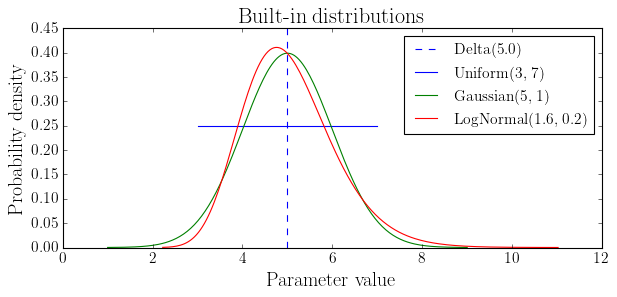

In [14]:
dists = {
    "Delta(5.0)": DeltaDistribution(5.0),
    "Uniform(3, 7)": UniformDistribution(3.0, 7.0),
    "Gaussian(5, 1)": GaussianDistribution(5.0, 1.0),
    "LogNormal(1.6, 0.2)": LogNormalDistribution(1.6, 0.2),
}

fig, ax = plt.subplots(figsize=(8, 4))
for name, d in dists.items():
    lo, hi = d.support
    if lo == hi:  # Delta
        ax.axvline(lo, ls="--", label=name)
        continue
    x = np.linspace(lo, hi, 200)
    pdf = np.array([d(xi) for xi in x])
    pdf = pdf / np.trapezoid(pdf, x)  # normalize for plotting
    ax.plot(x, pdf, label=name)

ax.set_xlabel("Parameter value")
ax.set_ylabel("Probability density")
ax.set_title("Built-in distributions")
ax.legend()
plt.tight_layout()
plt.show()

### Sympy expressions

Each distribution can display its PDF as a LaTeX equation:

In [15]:
GaussianDistribution(5.0, 1.0).get_sympy(var_name=r"\tau_{\rm spot}")
LogNormalDistribution(1.6, 0.2).get_sympy(var_name=r"\sigma_k")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

{'pdf': 2.5*sqrt(2)*exp(-(5.0*log(x) - 8.0)**2/2)/(sqrt(pi)*x)}

### Computing expectations

The `expectation(func)` method computes $E[f(x)]$ under the distribution via Gauss-Legendre quadrature:

In [16]:
d = GaussianDistribution(mu=5.0, sigma=1.0)

print(f"E[x]   = {d.expectation(lambda x: x):.4f}  (analytic: {d.mean:.4f})")
print(f"E[x^2] = {d.expectation(lambda x: x**2):.4f}  (analytic: {5**2 + 1**2:.4f})")
print(f"Var[x] = {d.expectation(lambda x: (x - d.mean)**2):.4f}  (analytic: {1**2:.4f})")

E[x]   = 5.0000  (analytic: 5.0000)
E[x^2] = 25.9989  (analytic: 26.0000)
Var[x] = 0.9989  (analytic: 1.0000)


---
## 2. Distributed `sigma_k` — amplitude uncertainty

The kernel amplitude `sigma_k` appears as a prefactor:

$$K(\tau) = \sigma_k^2 \cdot R_\Gamma(\tau) \cdot (\text{visibility terms})$$

When `sigma_k` is a distribution, the kernel replaces $\sigma_k^2$ with $E[\sigma_k^2]$. For a Gaussian with mean $\mu$ and std $\sigma$:

$$E[\sigma_k^2] = \mu^2 + \sigma^2$$

This is exact and analytic — no numerical integration needed.

In [17]:
env = TrapezoidSymmetricEnvelope(lspot=10.0, tau_spot=3.0)
vis = VisibilityFunction(peq=8.0, kappa=0.2, inc=np.pi / 3)

# Fixed sigma_k
model_fixed = SpotEvolutionModel(envelope=env, visibility=vis, sigma_k=0.01)

# Distributed sigma_k: same mean, but with spread
model_dist = SpotEvolutionModel(
    envelope=env, visibility=vis,
    sigma_k=GaussianDistribution(mu=0.01, sigma=0.003),
)

print(f"Fixed:       sigma_k = {model_fixed.sigma_k},  E[sigma_k^2] = {model_fixed.sigma_k_sq_expected:.2e}")
print(f"Distributed: sigma_k = {model_dist.sigma_k},  E[sigma_k^2] = {model_dist.sigma_k_sq_expected:.2e}")
print(f"Ratio: {model_dist.sigma_k_sq_expected / model_fixed.sigma_k_sq_expected:.3f}")

Fixed:       sigma_k = 0.01,  E[sigma_k^2] = 1.00e-04
Distributed: sigma_k = 0.01,  E[sigma_k^2] = 1.09e-04
Ratio: 1.090


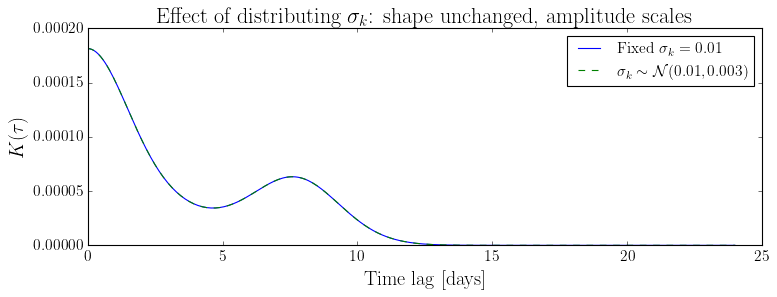

In [18]:
lag = np.linspace(0, 3 * 8.0, 300)

K_fixed = AnalyticKernel(model_fixed).kernel(lag)
K_dist = AnalyticKernel(model_dist).kernel(lag)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(lag, np.array(K_fixed), label=r"Fixed $\sigma_k = 0.01$")
ax.plot(lag, np.array(K_dist), "--", label=r"$\sigma_k \sim \mathcal{N}(0.01, 0.003)$")
ax.set_xlabel("Time lag [days]")
ax.set_ylabel(r"$K(\tau)$")
ax.set_title(r"Effect of distributing $\sigma_k$: shape unchanged, amplitude scales")
ax.legend()
plt.tight_layout()
plt.show()

The kernel shape is identical — only the amplitude changes by the factor $E[\sigma_k^2] / \sigma_k^2 = 1 + (\sigma/\mu)^2$.

---
## 3. Distributed `lspot` — spot lifetime variability

The plateau duration `lspot` appears nonlinearly inside the envelope autocorrelation $R_\Gamma(\tau)$. Marginalizing over a distribution of `lspot` produces a **mixture** of autocorrelations, which smooths the sharp cutoff at `lspot + 2*tau_spot`.

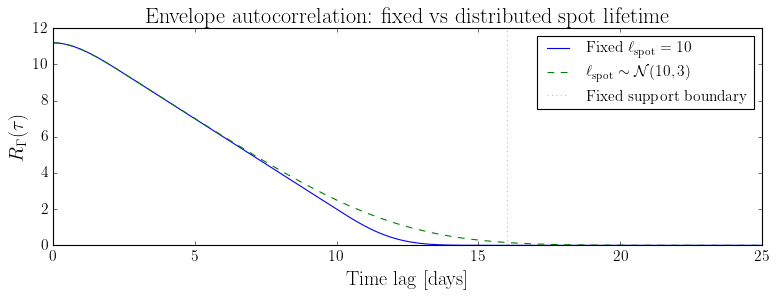

In [19]:
env_fixed = TrapezoidSymmetricEnvelope(lspot=10.0, tau_spot=3.0)
env_dist = TrapezoidSymmetricEnvelope(
    lspot=GaussianDistribution(mu=10.0, sigma=3.0),
    tau_spot=3.0,
)

lag = np.linspace(0, 25, 300)
R_fixed = np.array(env_fixed.R_Gamma(lag))
R_dist = np.array(env_dist.R_Gamma(lag))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(lag, R_fixed, label=r"Fixed $\ell_{\rm spot} = 10$")
ax.plot(lag, R_dist, "--", label=r"$\ell_{\rm spot} \sim \mathcal{N}(10, 3)$")
ax.axvline(10 + 2*3, color="gray", ls=":", alpha=0.5, label="Fixed support boundary")
ax.set_xlabel("Time lag [days]")
ax.set_ylabel(r"$R_\Gamma(\tau)$")
ax.set_title("Envelope autocorrelation: fixed vs distributed spot lifetime")
ax.legend()
plt.tight_layout()
plt.show()

The distributed version has a smoother tail — the sharp cutoff at `lspot + 2*tau_spot` is blurred because different `lspot` values contribute at different lag ranges.

### Effect on the full kernel

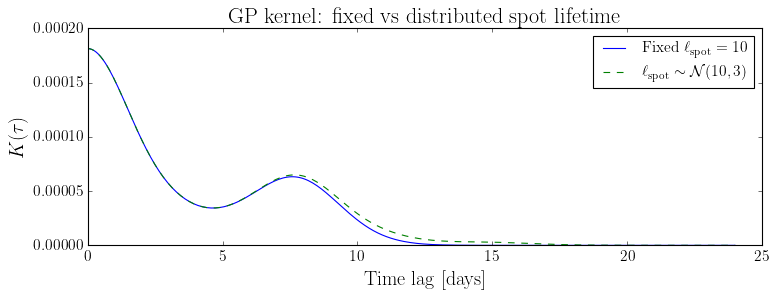

In [20]:
vis = VisibilityFunction(peq=8.0, kappa=0.2, inc=np.pi / 3)

model_fixed = SpotEvolutionModel(envelope=env_fixed, visibility=vis, sigma_k=0.01)
model_dist = SpotEvolutionModel(envelope=env_dist, visibility=vis, sigma_k=0.01)

lag = np.linspace(0, 3 * 8.0, 300)
K_fixed = np.array(AnalyticKernel(model_fixed).kernel(lag))
K_dist = np.array(AnalyticKernel(model_dist).kernel(lag))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(lag, K_fixed, label=r"Fixed $\ell_{\rm spot} = 10$")
ax.plot(lag, K_dist, "--", label=r"$\ell_{\rm spot} \sim \mathcal{N}(10, 3)$")
ax.set_xlabel("Time lag [days]")
ax.set_ylabel(r"$K(\tau)$")
ax.set_title("GP kernel: fixed vs distributed spot lifetime")
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Distributed `tau_spot` — emergence/decay timescale spread

Similarly, distributing `tau_spot` broadens the transition between the plateau and zero correlation:

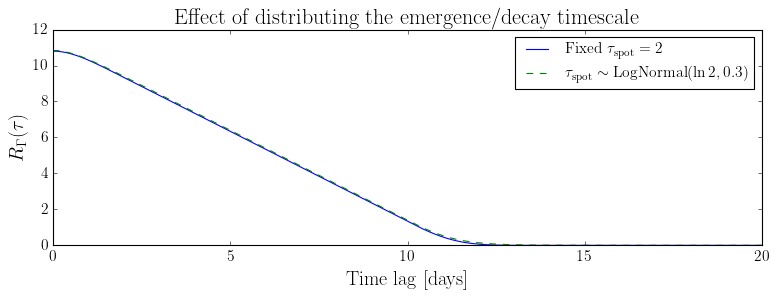

In [21]:
env_fixed = TrapezoidSymmetricEnvelope(lspot=10.0, tau_spot=2.0)
env_tau_dist = TrapezoidSymmetricEnvelope(
    lspot=10.0,
    tau_spot=LogNormalDistribution(mu=np.log(2.0), sigma=0.3),
)

lag = np.linspace(0, 20, 300)
R_fixed = np.array(env_fixed.R_Gamma(lag))
R_tau = np.array(env_tau_dist.R_Gamma(lag))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(lag, R_fixed, label=r"Fixed $\tau_{\rm spot} = 2$")
ax.plot(lag, R_tau, "--",
        label=r"$\tau_{\rm spot} \sim \mathrm{LogNormal}(\ln 2, 0.3)$")
ax.set_xlabel("Time lag [days]")
ax.set_ylabel(r"$R_\Gamma(\tau)$")
ax.set_title("Effect of distributing the emergence/decay timescale")
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Combining multiple distributed parameters

All distributable parameters can be combined freely:

In [22]:
model_all = SpotEvolutionModel(
    envelope=TrapezoidSymmetricEnvelope(
        lspot=GaussianDistribution(mu=10.0, sigma=2.0),
        tau_spot=LogNormalDistribution(mu=np.log(3.0), sigma=0.3),
    ),
    visibility=VisibilityFunction(peq=8.0, kappa=0.2, inc=np.pi / 3),
    sigma_k=GaussianDistribution(mu=0.01, sigma=0.003),
)

# The model reports means for backward compat
print("Model parameters (means):")
print(f"  sigma_k  = {model_all.sigma_k:.4f}")
print(f"  lspot    = {model_all.lspot:.1f}")
print(f"  tau_spot = {model_all.tau_spot:.2f}")
print(f"  E[sigma_k^2] = {model_all.sigma_k_sq_expected:.2e}")
print()

# Check which parameters are distributions
print("Distributed parameters:")
print(f"  sigma_k:  {is_distributed(model_all.sigma_k_distribution)}")
print(f"  lspot:    {is_distributed(model_all.envelope.lspot_distribution)}")
print(f"  tau_spot: {is_distributed(model_all.envelope.tau_spot_distribution)}")

Model parameters (means):
  sigma_k  = 0.0100
  lspot    = 10.0
  tau_spot = 3.14
  E[sigma_k^2] = 1.09e-04

Distributed parameters:
  sigma_k:  True
  lspot:    True
  tau_spot: True


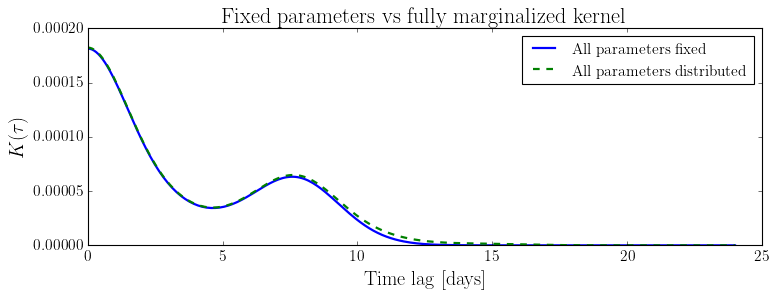

In [23]:
# Compare: all fixed vs all distributed
model_fixed = SpotEvolutionModel(
    envelope=TrapezoidSymmetricEnvelope(lspot=10.0, tau_spot=3.0),
    visibility=VisibilityFunction(peq=8.0, kappa=0.2, inc=np.pi / 3),
    sigma_k=0.01,
)

lag = np.linspace(0, 3 * 8.0, 300)
K_fixed = np.array(AnalyticKernel(model_fixed).kernel(lag))
K_all = np.array(AnalyticKernel(model_all).kernel(lag))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(lag, K_fixed, label="All parameters fixed", lw=2)
ax.plot(lag, K_all, "--", label="All parameters distributed", lw=2)
ax.set_xlabel("Time lag [days]")
ax.set_ylabel(r"$K(\tau)$")
ax.set_title("Fixed parameters vs fully marginalized kernel")
ax.legend()
plt.tight_layout()
plt.show()

---
## 6. Custom distributions

Subclass `ParameterDistribution` to define your own. Only `support` and `__call__` are required:

In [25]:
class BetaDistribution(ParameterDistribution):
    """Beta distribution scaled to [lo, hi]."""

    def __init__(self, a, b, lo=0.0, hi=1.0):
        from scipy.special import beta as beta_func
        self.a, self.b = float(a), float(b)
        self.lo, self.hi = float(lo), float(hi)
        self._B = beta_func(self.a, self.b)

    @property
    def support(self):
        return (self.lo, self.hi)

    def __call__(self, x):
        t = (x - self.lo) / (self.hi - self.lo)
        if t <= 0 or t >= 1:
            return 0.0
        return t ** (self.a - 1) * (1 - t) ** (self.b - 1) / self._B
    
    def sympy_pdf(self):                                  
        import sympy as sp                                                                                                  
        x = sp.Symbol("x")                                                                                                  
        a, b = sp.Float(self.a), sp.Float(self.b)                                                                           
        lo, hi = sp.Float(self.lo), sp.Float(self.hi)                                                                       
        t = (x - lo) / (hi - lo)                                                                                            
        return t ** (a - 1) * (1 - t) ** (b - 1) / (                                                                        
            (hi - lo) * sp.beta(a, b)) 

In [26]:
# Use it for lspot: skewed towards shorter lifetimes
lspot_dist = BetaDistribution(a=2, b=5, lo=2.0, hi=15.0)

print(f"Mean lspot: {lspot_dist.mean:.2f} days")
print(f"E[lspot^2]: {lspot_dist.expectation(lambda x: x**2):.2f}")

env = TrapezoidSymmetricEnvelope(lspot=lspot_dist, tau_spot=2.0)
model = SpotEvolutionModel(
    envelope=env,
    visibility=VisibilityFunction(peq=8.0, kappa=0.2, inc=np.pi / 3),
    sigma_k=0.01,
)
K = AnalyticKernel(model).kernel(np.linspace(0, 24, 200))
print(f"Kernel K(0) = {float(K[0]):.2e}")

Mean lspot: 5.71 days
E[lspot^2]: 36.96
Kernel K(0) = 1.05e-04


In [28]:
ldist_eqn = lspot_dist.get_sympy(var_name=r"\ell_{\rm spot}")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

---
## Summary

| Feature | How it works |
|---|---|
| `sigma_k = float` | Fixed amplitude (default, unchanged) |
| `sigma_k = GaussianDistribution(mu, sigma)` | Replaces $\sigma_k^2$ with $E[\sigma_k^2]$ (analytic) |
| `lspot = GaussianDistribution(mu, sigma)` | Marginalizes $R_\Gamma$ over lspot via quadrature |
| `tau_spot = LogNormalDistribution(mu, sigma)` | Marginalizes $R_\Gamma$ over tau_spot via quadrature |
| Custom `ParameterDistribution` subclass | Implement `support` and `__call__`; everything else works automatically |

All existing code that passes plain floats continues to work unchanged — floats are internally wrapped as `DeltaDistribution` with zero overhead.